# One faulty gate

We model the first encoding gate as $\widetilde{CX}_{0,1}=R_x^{(1)}(\epsilon)CX_{0,1}$. All other gates and measurements remain ideal.

##  Theory

For $|\psi_L\rangle=\alpha|000\rangle+\beta|111\rangle$, the residual rotation gives

$$|\widetilde{\psi}_L\rangle=\cos(\epsilon/2)|\psi_L\rangle-i\sin(\epsilon/2)X_1|\psi_L\rangle.$$

The two branches have syndromes `00` and `11`, so $P(00)=\cos^2(\epsilon/2)$ and $P(11)=\sin^2(\epsilon/2)$.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit.visualization import plot_histogram

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qec_calibration import (
    build_syndrome_circuit,
    counts_to_probabilities,
    run_error_sweep,
    run_faulty_cx_syndrome,
    theoretical_syndrome_probabilities,
)

EPSILON = 0.20
SHOTS = 1024
SEED = 42

## The circuit

The error is in the Aer `NoiseModel`, so the drawn circuit looks ideal. It is attached only to the ordered physical pair `[0, 1]`.

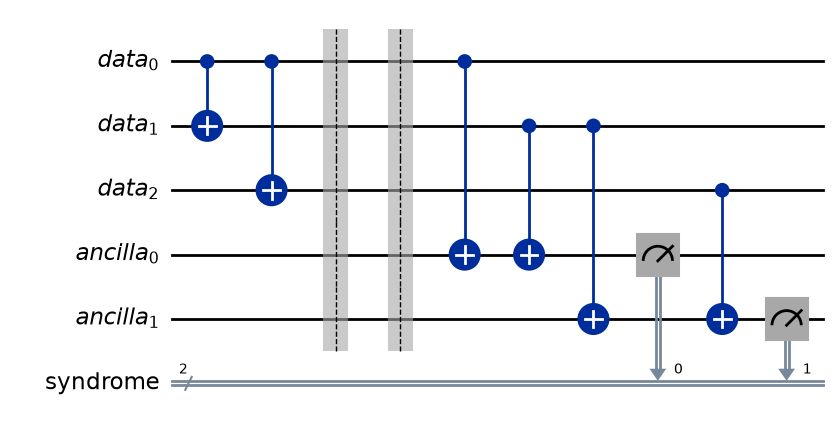

In [8]:
circuit = build_syndrome_circuit(error_qubit=None, logical_value=0)
circuit.draw(output="mpl", fold=-1)

## Predict and sample the syndrome distribution



In [9]:
theory = theoretical_syndrome_probabilities(EPSILON)
counts = run_faulty_cx_syndrome(EPSILON, shots=SHOTS, seed=SEED)
observed = counts_to_probabilities(counts)

comparison = pd.DataFrame({
    "Syndrome": list(theory),
    "Aer counts": [counts.get(s, 0) for s in theory],
    "Aer probability": [observed[s] for s in theory],
    "Theory": [theory[s] for s in theory],
})
comparison["Absolute difference"] = abs(comparison["Aer probability"] - comparison["Theory"])
comparison

,Syndrome,Aer counts,Aer probability,Theory,Absolute difference
0,00,1014,0.990234,0.990033,0.000201
1,10,0,0.000000,0.000000,0.000000
2,11,10,0.009766,0.009967,0.000201
3,01,0,0.000000,0.000000,0.000000


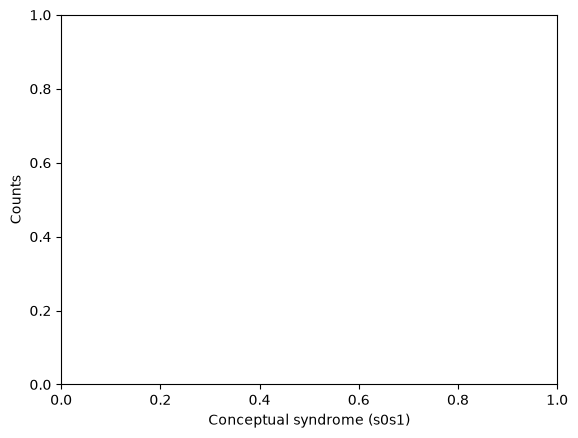

In [10]:
plot_histogram(counts, title=f"Faulty CX(0, 1): epsilon = {EPSILON:.2f} rad")
plt.xlabel("Conceptual syndrome (s0s1)")
plt.ylabel("Counts")
plt.show()

## Sweep the error angle

The `11` frequency is our observable calibration signal. The next stage will vary a compensating angle to minimize it.

In [11]:
epsilon_values = np.linspace(0.0, 0.8, 17)
sweep = pd.DataFrame(run_error_sweep(epsilon_values, shots=1024, seed=SEED))
sweep

,epsilon,shots,count_00,count_10,count_11,count_01,p00_empirical,p10_empirical,p11_empirical,p01_empirical,p00_theory,p10_theory,p11_theory,p01_theory,absolute_error_p11,expected_syndrome,p_expected_empirical,p_expected_theory,calibration_signal_empirical,calibration_signal_theory
0,0.00,1024,1024,0,0,0,1.000000,0.0,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.000000,00,1.000000,1.000000,0.000000,0.000000
1,0.05,1024,1024,0,0,0,1.000000,0.0,0.000000,0.0,0.999375,0.0,0.000625,0.0,0.000625,00,1.000000,0.999375,0.000000,0.000625
2,0.10,1024,1022,0,2,0,0.998047,0.0,0.001953,0.0,0.997502,0.0,0.002498,0.0,0.000545,00,0.998047,0.997502,0.001953,0.002498
3,0.15,1024,1016,0,8,0,0.992188,0.0,0.007812,0.0,0.994386,0.0,0.005614,0.0,0.002198,00,0.992188,0.994386,0.007812,0.005614
4,0.20,1024,1019,0,5,0,0.995117,0.0,0.004883,0.0,0.990033,0.0,0.009967,0.0,0.005084,00,0.995117,0.990033,0.004883,0.009967
5,0.25,1024,1010,0,14,0,0.986328,0.0,0.013672,0.0,0.984456,0.0,0.015544,0.0,0.001872,00,0.986328,0.984456,0.013672,0.015544
6,0.30,1024,1004,0,20,0,0.980469,0.0,0.019531,0.0,0.977668,0.0,0.022332,0.0,0.002801,00,0.980469,0.977668,0.019531,0.022332
7,0.35,1024,994,0,30,0,0.970703,0.0,0.029297,0.0,0.969686,0.0,0.030314,0.0,0.001017,00,0.970703,0.969686,0.029297,0.030314
8,0.40,1024,984,0,40,0,0.960938,0.0,0.039062,0.0,0.960530,0.0,0.039470,0.0,0.000407,00,0.960938,0.960530,0.039062,0.039470
9,0.45,1024,978,0,46,0,0.955078,0.0,0.044922,0.0,0.950224,0.0,0.049776,0.0,0.004855,00,0.955078,0.950224,0.044922,0.049776


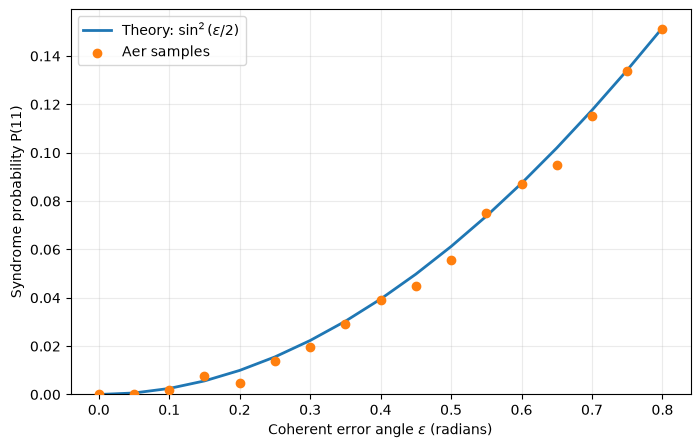

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep["epsilon"], sweep["p11_theory"], label=r"Theory: $\sin^2(\epsilon/2)$", linewidth=2)
ax.scatter(sweep["epsilon"], sweep["p11_empirical"], label="Aer samples", color="tab:orange", zorder=3)
ax.set(xlabel=r"Coherent error angle $\epsilon$ (radians)", ylabel="Syndrome probability P(11)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Numerical checks

In [13]:
p_11 = theory["11"]
standard_error = np.sqrt(p_11 * (1 - p_11) / SHOTS)
assert set(counts) <= {"00", "11"}
assert abs(observed["11"] - p_11) <= 5 * standard_error + 1 / SHOTS
assert sweep["absolute_error_p11"].max() < 0.03
print(f"Injected angle: {EPSILON:.3f} rad")
print(f"Theory P(11):   {p_11:.6f}")
print(f"Aer P(11):      {observed['11']:.6f}")
print("Analytic-versus-Aer validation: PASS")

Injected angle: 0.200 rad
Theory P(11):   0.009967
Aer P(11):      0.009766
Analytic-versus-Aer validation: PASS


# Add a deliberate physical bit-flip error

The analysis above remains the coherent-gate-error-only baseline. We now inject an ideal physical $X_1$ after encoding and before syndrome extraction:

$$X_1R_x^{(1)}(\epsilon)|\psi_L\rangle = \cos(\epsilon/2)X_1|\psi_L\rangle-i\sin(\epsilon/2)|\psi_L\rangle.$$

The intended $X_1$ branch has syndrome `11`, while the residual branch has syndrome `00`. Therefore $P(11)=\cos^2(\epsilon/2)$ and $P(00)=\sin^2(\epsilon/2)$. The correct calibration signal is now $1-P(11)$, not the total nonzero-syndrome rate.

## Circuit with an injected $X_1$ error

The drawn circuit shows the deliberate physical error. The coherent $R_x(\epsilon)$ fault still lives in the Aer noise model and therefore does not appear in the drawing.

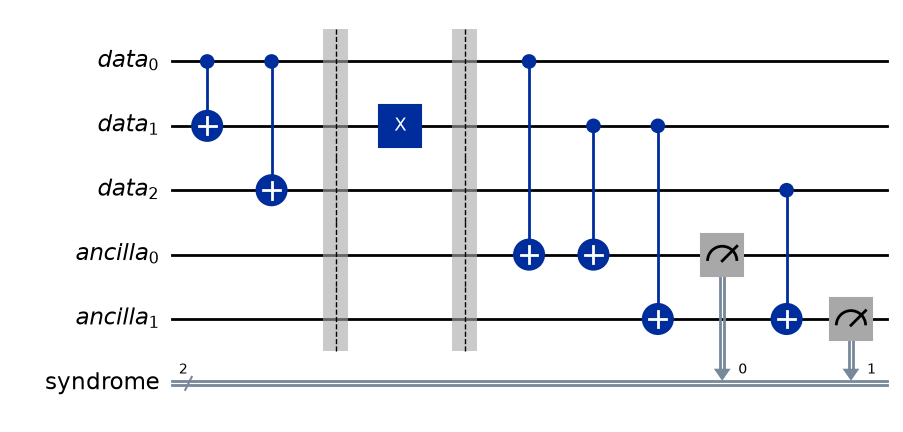

In [14]:
circuit_x1 = build_syndrome_circuit(error_qubit=1, logical_value=0)
circuit_x1.draw(output="mpl", fold=-1)

## Predict and sample the combined-error syndrome distribution

In [15]:
theory_x1 = theoretical_syndrome_probabilities(EPSILON, error_qubit=1)
counts_x1 = run_faulty_cx_syndrome(
    EPSILON, error_qubit=1, shots=SHOTS, seed=SEED
)
observed_x1 = counts_to_probabilities(counts_x1)

comparison_x1 = pd.DataFrame({
    "Syndrome": list(theory_x1),
    "Aer counts": [counts_x1.get(s, 0) for s in theory_x1],
    "Aer probability": [observed_x1[s] for s in theory_x1],
    "Theory": [theory_x1[s] for s in theory_x1],
})
comparison_x1["Absolute difference"] = abs(
    comparison_x1["Aer probability"] - comparison_x1["Theory"]
)
comparison_x1

,Syndrome,Aer counts,Aer probability,Theory,Absolute difference
0,00,3,0.00293,0.009967,0.007037
1,10,0,0.00000,0.000000,0.000000
2,11,1021,0.99707,0.990033,0.007037
3,01,0,0.00000,0.000000,0.000000


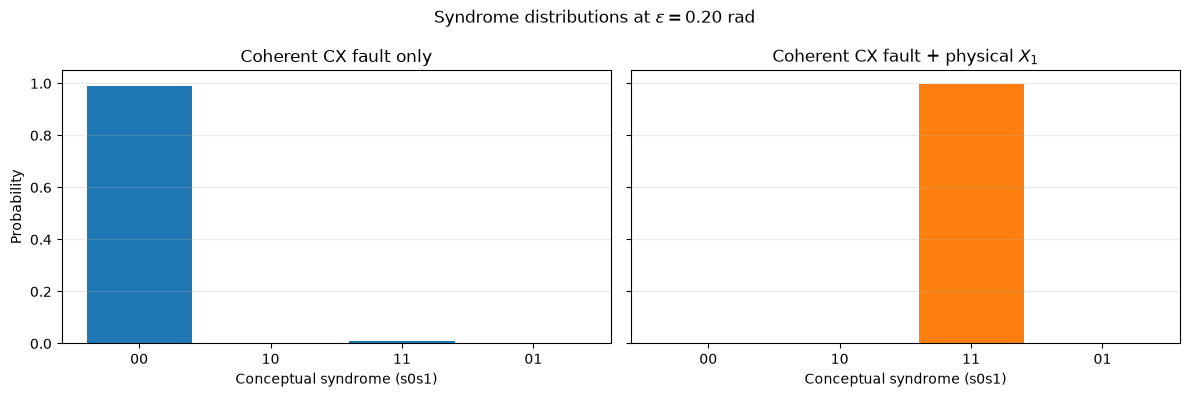

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
syndrome_order = list(theory)
axes[0].bar(syndrome_order, [observed[s] for s in syndrome_order])
axes[0].set_title("Coherent CX fault only")
axes[1].bar(
    syndrome_order,
    [observed_x1[s] for s in syndrome_order],
    color="tab:orange",
)
axes[1].set_title(r"Coherent CX fault + physical $X_1$")
for ax in axes:
    ax.set_xlabel("Conceptual syndrome (s0s1)")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Probability")
fig.suptitle(rf"Syndrome distributions at $\epsilon={EPSILON:.2f}$ rad")
fig.tight_layout()
plt.show()

## Sweep the gate-error angle with $X_1$ present

With no physical error, $P(11)=\sin^2(\epsilon/2)$. With an injected $X_1$, the same curve is the probability of leaving the expected `11` sector: $1-P(11)=P(00)=\sin^2(\epsilon/2)$.

In [17]:
sweep_x1 = pd.DataFrame(
    run_error_sweep(
        epsilon_values, error_qubit=1, shots=1024, seed=SEED
    )
)
sweep_x1

,epsilon,shots,count_00,count_10,count_11,count_01,p00_empirical,p10_empirical,p11_empirical,p01_empirical,p00_theory,p10_theory,p11_theory,p01_theory,absolute_error_p11,expected_syndrome,p_expected_empirical,p_expected_theory,calibration_signal_empirical,calibration_signal_theory
0,0.00,1024,0,0,1024,0,0.000000,0.0,1.000000,0.0,0.000000,0.0,1.000000,0.0,0.000000,11,1.000000,1.000000,0.000000,0.000000
1,0.05,1024,0,0,1024,0,0.000000,0.0,1.000000,0.0,0.000625,0.0,0.999375,0.0,0.000625,11,1.000000,0.999375,0.000000,0.000625
2,0.10,1024,4,0,1020,0,0.003906,0.0,0.996094,0.0,0.002498,0.0,0.997502,0.0,0.001408,11,0.996094,0.997502,0.003906,0.002498
3,0.15,1024,2,0,1022,0,0.001953,0.0,0.998047,0.0,0.005614,0.0,0.994386,0.0,0.003661,11,0.998047,0.994386,0.001953,0.005614
4,0.20,1024,6,0,1018,0,0.005859,0.0,0.994141,0.0,0.009967,0.0,0.990033,0.0,0.004107,11,0.994141,0.990033,0.005859,0.009967
5,0.25,1024,15,0,1009,0,0.014648,0.0,0.985352,0.0,0.015544,0.0,0.984456,0.0,0.000895,11,0.985352,0.984456,0.014648,0.015544
6,0.30,1024,18,0,1006,0,0.017578,0.0,0.982422,0.0,0.022332,0.0,0.977668,0.0,0.004754,11,0.982422,0.977668,0.017578,0.022332
7,0.35,1024,30,0,994,0,0.029297,0.0,0.970703,0.0,0.030314,0.0,0.969686,0.0,0.001017,11,0.970703,0.969686,0.029297,0.030314
8,0.40,1024,41,0,983,0,0.040039,0.0,0.959961,0.0,0.039470,0.0,0.960530,0.0,0.000570,11,0.959961,0.960530,0.040039,0.039470
9,0.45,1024,53,0,971,0,0.051758,0.0,0.948242,0.0,0.049776,0.0,0.950224,0.0,0.001981,11,0.948242,0.950224,0.051758,0.049776


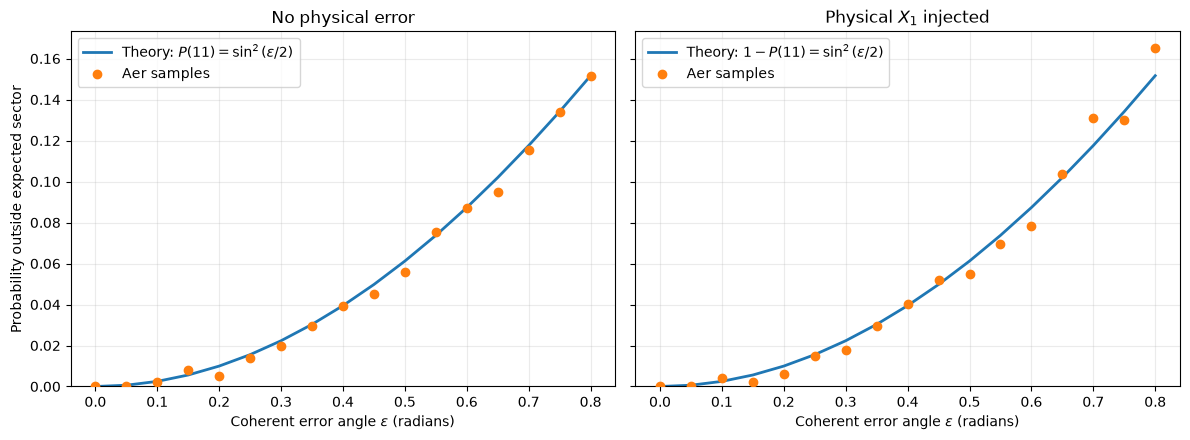

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].plot(
    sweep["epsilon"], sweep["p11_theory"],
    label=r"Theory: $P(11)=\sin^2(\epsilon/2)$", linewidth=2,
)
axes[0].scatter(
    sweep["epsilon"], sweep["p11_empirical"],
    label="Aer samples", color="tab:orange", zorder=3,
)
axes[0].set_title("No physical error")
axes[0].set_ylabel("Probability outside expected sector")

axes[1].plot(
    sweep_x1["epsilon"], sweep_x1["calibration_signal_theory"],
    label=r"Theory: $1-P(11)=\sin^2(\epsilon/2)$", linewidth=2,
)
axes[1].scatter(
    sweep_x1["epsilon"], sweep_x1["calibration_signal_empirical"],
    label="Aer samples", color="tab:orange", zorder=3,
)
axes[1].set_title(r"Physical $X_1$ injected")
for ax in axes:
    ax.set_xlabel(r"Coherent error angle $\epsilon$ (radians)")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
plt.show()

## Generalize to every physical error location

Because the coherent residual acts on qubit 1, it XORs the syndrome of the deliberately injected error with `11`. The dominant branch always carries the intended physical-error syndrome, while the smaller branch carries the combined-error syndrome.

In [19]:
error_labels = {None: "None", 0: "X0", 1: "X1", 2: "X2"}
expected_syndromes = {None: "00", 0: "10", 1: "11", 2: "01"}
rows = []
for error_qubit, error_label in error_labels.items():
    probabilities = theoretical_syndrome_probabilities(
        EPSILON, error_qubit=error_qubit
    )
    rows.append({
        "Physical error": error_label,
        "Expected syndrome": expected_syndromes[error_qubit],
        **{f"P({s})": probabilities[s] for s in syndrome_order},
    })
all_error_theory = pd.DataFrame(rows)
all_error_theory

,Physical error,Expected syndrome,P(00),P(10),P(11),P(01)
0,None,00,0.990033,0.000000,0.009967,0.000000
1,X0,10,0.000000,0.990033,0.000000,0.009967
2,X1,11,0.009967,0.000000,0.990033,0.000000
3,X2,01,0.000000,0.009967,0.000000,0.990033


In [20]:
all_error_results = []
for error_qubit, error_label in error_labels.items():
    case_counts = run_faulty_cx_syndrome(
        EPSILON, error_qubit=error_qubit, shots=SHOTS, seed=SEED
    )
    case_observed = counts_to_probabilities(case_counts)
    case_theory = theoretical_syndrome_probabilities(
        EPSILON, error_qubit=error_qubit
    )
    for syndrome in syndrome_order:
        all_error_results.append({
            "Physical error": error_label,
            "Syndrome": syndrome,
            "Aer probability": case_observed[syndrome],
            "Theory": case_theory[syndrome],
        })
all_error_comparison = pd.DataFrame(all_error_results)
all_error_comparison

,Physical error,Syndrome,Aer probability,Theory
0,None,00,0.990234,0.990033
1,None,10,0.000000,0.000000
2,None,11,0.009766,0.009967
3,None,01,0.000000,0.000000
4,X0,00,0.000000,0.000000
5,X0,10,0.990234,0.990033
6,X0,11,0.000000,0.000000
7,X0,01,0.009766,0.009967
8,X1,00,0.002930,0.009967
9,X1,10,0.000000,0.000000


## Numerical checks for the injected-error extension

In [21]:
p_expected_x1 = theory_x1["11"]
standard_error_x1 = np.sqrt(
    p_expected_x1 * (1 - p_expected_x1) / SHOTS
)
assert set(counts_x1) <= {"00", "11"}
assert np.isclose(theory_x1["11"], np.cos(EPSILON / 2) ** 2)
assert np.isclose(theory_x1["00"], np.sin(EPSILON / 2) ** 2)
assert abs(observed_x1["11"] - p_expected_x1) <= (
    5 * standard_error_x1 + 1 / SHOTS
)
assert np.allclose(
    sweep_x1["calibration_signal_theory"],
    sweep_x1["p00_theory"],
)
assert (
    all_error_comparison["Aer probability"]
    - all_error_comparison["Theory"]
).abs().max() < 0.03
print(f"Physical error: X1")
print(f"Theory P(11): {p_expected_x1:.6f}")
print(f"Aer P(11):    {observed_x1['11']:.6f}")
print("All injected-error validations: PASS")

Physical error: X1
Theory P(11): 0.990033
Aer P(11):    0.997070
All injected-error validations: PASS
